In [1]:
# run autoreload
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

In [2]:
import json
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display

# -------------------- Persistence --------------------
CONFIG_FILE = Path(".analysis_widget_config.json")

DEFAULTS = {
    "casa": True,
    "test": False,
    "data": False,
    "useDefault": False,
    "mode": "validation",
    "era": "2016",
    "dataset": "pythia",
    "pre": "outputs/validation_",
    "chunksize": 50000,
    "chunksize_test": 200000,
    "group_mode": "all_in_one",
    "prependstr": "root://xcache/",
    "systematics": "None",
    "jet_systematics": "None",
}


def load_config():
    """Load last saved config if available, otherwise return defaults."""
    if CONFIG_FILE.exists():
        try:
            with open(CONFIG_FILE, "r") as f:
                loaded = json.load(f)

            config = DEFAULTS.copy()
            config.update(loaded)
            return config

        except Exception as e:
            print(f"Warning: could not read {CONFIG_FILE}: {e}")
            print("Falling back to defaults.")
    return DEFAULTS.copy()


def save_config(config):
    """Save current config to disk."""
    try:
        with open(CONFIG_FILE, "w") as f:
            json.dump(config, f, indent=2)
    except Exception as e:
        print(f"Warning: could not save config: {e}")


def apply_config_to_widgets(config):
    """Push config values into widgets."""
    casa_w.value = config["casa"]
    test_w.value = config["test"]
    data_w.value = config["data"]
    useDefault_w.value = config["useDefault"]
    mode_w.value = config["mode"]
    era_w.value = config["era"]
    dataset_w.value = config["dataset"]
    pre_w.value = config["pre"]
    chunksize_w.value = config["chunksize"]
    chunksize_test_w.value = config["chunksize_test"]
    group_mode_w.value = config["group_mode"]
    prependstr_w.value = config["prependstr"]
    systematics_w.value = config["systematics"]
    jet_systematics_w.value = config["jet_systematics"]


def get_config_from_widgets():
    """Pull current widget values into a config dict."""
    return {
        "casa": casa_w.value,
        "test": test_w.value,
        "data": data_w.value,
        "useDefault": useDefault_w.value,
        "mode": mode_w.value,
        "era": era_w.value,
        "dataset": dataset_w.value,
        "pre": pre_w.value,
        "chunksize": chunksize_w.value,
        "chunksize_test": chunksize_test_w.value,
        "group_mode": group_mode_w.value,
        "prependstr": prependstr_w.value,
        "systematics": systematics_w.value,
        "jet_systematics": jet_systematics_w.value,
    }


def parse_list_or_none(text):
    text = text.strip()
    if text.lower() == "none" or text == "":
        return None
    return [x.strip() for x in text.split(",")]


def apply_widget_values(save=False, show_output=True):
    """
    Read current widget values and apply them to notebook variables.
    Optionally save them and/or print them.
    """
    global casa, test, mode, era, data, dataset, pre
    global systematics_list, jet_systematics_list
    global chunksize, chunksize_test, useDefault
    global group_mode, prependstr

    casa = casa_w.value
    test = test_w.value
    mode = mode_w.value
    era = era_w.value
    data = data_w.value
    dataset = dataset_w.value
    pre = pre_w.value
    systematics_list = parse_list_or_none(systematics_w.value)
    jet_systematics_list = parse_list_or_none(jet_systematics_w.value)
    chunksize = chunksize_w.value
    chunksize_test = chunksize_test_w.value
    useDefault = useDefault_w.value
    group_mode = group_mode_w.value
    prependstr = prependstr_w.value

    if save:
        save_config(get_config_from_widgets())

    if show_output:
        with output:
            output.clear_output()
            print("Applied settings:")
            print(f"casa = {casa}")
            print(f"test = {test}")
            print(f"mode = {mode}")
            print(f"era = {era}")
            print(f"data = {data}")
            print(f"dataset = {dataset}")
            print(f"pre = {pre}")
            print(f"systematics_list = {systematics_list}")
            print(f"jet_systematics_list = {jet_systematics_list}")
            print(f"chunksize = {chunksize}")
            print(f"chunksize_test = {chunksize_test}")
            print(f"useDefault = {useDefault}")
            print(f"group_mode = {group_mode}")
            print(f"prependstr = {prependstr}")
            if save:
                print(f"\nSaved to: {CONFIG_FILE}")


# Load last saved config (or defaults if none exists)
CONFIG = load_config()

# -------------------- Widgets --------------------
casa_w = widgets.Checkbox(value=CONFIG["casa"], description="casa")
test_w = widgets.Checkbox(value=CONFIG["test"], description="test")
data_w = widgets.Checkbox(value=CONFIG["data"], description="data")
useDefault_w = widgets.Checkbox(value=CONFIG["useDefault"], description="useDefault")

mode_w = widgets.Dropdown(
    options=["validation", "minimal_rho", "rho_jk"],
    value=CONFIG["mode"],
    description="mode"
)

era_w = widgets.Dropdown(
    options=["2016", "2016APV", "2017", "2018", "all"],
    value=CONFIG["era"],
    description="era"
)

dataset_w = widgets.Dropdown(
    options=["pythia", "herwig", "st", "powheg", "backgrounds"],
    value=CONFIG["dataset"],
    description="dataset"
)

pre_w = widgets.Text(
    value=CONFIG["pre"],
    description="pre"
)

chunksize_w = widgets.IntText(
    value=CONFIG["chunksize"],
    description="chunksize"
)

chunksize_test_w = widgets.IntText(
    value=CONFIG["chunksize_test"],
    description="test chunk"
)

group_mode_w = widgets.Dropdown(
    options=["all_in_one", "per_group"],
    value=CONFIG["group_mode"],
    description="group_mode"
)

prependstr_w = widgets.Text(
    value=CONFIG["prependstr"],
    description="prependstr"
)

systematics_w = widgets.Text(
    value=CONFIG["systematics"],
    description="systematics"
)

jet_systematics_w = widgets.Text(
    value=CONFIG["jet_systematics"],
    description="jet syst"
)

run_button = widgets.Button(
    description="Apply settings",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset to defaults",
    button_style="warning"
)

output = widgets.Output()

# -------------------- Layout --------------------
ui = widgets.VBox([
    widgets.HTML("<h3>Analysis configuration</h3>"),
    widgets.HBox([casa_w, test_w, data_w, useDefault_w]),
    mode_w,
    era_w,
    dataset_w,
    pre_w,
    systematics_w,
    jet_systematics_w,
    chunksize_w,
    chunksize_test_w,
    group_mode_w,
    prependstr_w,
    widgets.HBox([run_button, reset_button]),
    output
])

display(ui)

# -------------------- Button actions --------------------
def on_run_clicked(b):
    apply_widget_values(save=True, show_output=True)


def on_reset_clicked(b):
    apply_config_to_widgets(DEFAULTS)
    apply_widget_values(save=True, show_output=True)

    with output:
        output.clear_output()
        print("Reset all widget values to defaults and applied them.")
        print(f"Saved defaults to: {CONFIG_FILE}")
        print(f"casa = {casa}")
        print(f"test = {test}")
        print(f"mode = {mode}")
        print(f"era = {era}")
        print(f"data = {data}")
        print(f"dataset = {dataset}")
        print(f"pre = {pre}")
        print(f"systematics_list = {systematics_list}")
        print(f"jet_systematics_list = {jet_systematics_list}")
        print(f"chunksize = {chunksize}")
        print(f"chunksize_test = {chunksize_test}")
        print(f"useDefault = {useDefault}")
        print(f"group_mode = {group_mode}")
        print(f"prependstr = {prependstr}")


run_button.on_click(on_run_clicked)
reset_button.on_click(on_reset_clicked)

# -------------------- Auto-apply on cell execution --------------------
apply_widget_values(save=False, show_output=True)

In [6]:
# HT bins only used for pythia (your convention)
ht_bins = ['100to200','200to400','400to600','600to800','800to1200','1200to2500','2500toInf']

# Paths relative to notebook working dir
SAMPLES_DATA_DIR = "samples"
SAMPLES_MC_DIR   = "samples_mc"
SAMPLES_BKG_DIR  = "samples_mc/backgrounds"

# In[3]:  -------------------- Sample lists (list-of-lists is intentional) --------------------
class SamplePath:
    """Holds list-of-lists so you can run per-group or all-in-one."""

    def __init__(self, era: str):
        self.era = era

        if era == "all":
            self.data = [
                ['SingleMuon_UL2018.txt', 'EGamma_UL2018.txt'],
                ['SingleMuon_UL2017.txt', 'SingleElectron_UL2017.txt'],
                ['SingleMuon_UL2016APV.txt', 'SingleElectron_UL2016APV.txt'],
                ['SingleMuon_UL2016.txt', 'SingleElectron_UL2016.txt'],
            ]
            self.pythia = [
                ['pythia_UL16NanoAODAPVv9.txt'],
                ['pythia_UL16NanoAODv9.txt'],
                ['pythia_UL17NanoAODv9.txt'],
                ['pythia_UL18NanoAODv9.txt'],
            ]
            self.herwig = [
                ['herwig7_UL16NanoAODAPVv9_inclusive.txt'],
                ['herwig7_UL16NanoAODv9_inclusive.txt'],
                ['herwig7_UL17NanoAODv9_inclusive.txt'],
                ['herwig7_UL18NanoAODv9_inclusive.txt'],
            ]

        elif era == "2018":
            self.data   = [['SingleMuon_UL2018.txt', 'EGamma_UL2018.txt']]
            self.pythia = [['pythia_UL18NanoAODv9.txt']]
            self.herwig = [['herwig7_UL18NanoAODv9_inclusive.txt']]

        elif era == "2017":
            self.data   = [['SingleMuon_UL2017.txt', 'SingleElectron_UL2017.txt']]
            self.pythia = [['pythia_UL17NanoAODv9.txt']]
            self.herwig = [['herwig7_UL17NanoAODv9_inclusive.txt']]

        elif era == "2016APV":
            self.data   = [['SingleMuon_UL2016APV.txt', 'SingleElectron_UL2016APV.txt']]
            self.pythia = [['pythia_UL16NanoAODAPVv9.txt']]
            self.herwig = [['herwig7_UL16NanoAODAPVv9_inclusive.txt']]

        elif era == "2016":
            self.data   = [['SingleMuon_UL2016.txt', 'SingleElectron_UL2016.txt']]
            self.pythia = [['pythia_UL16NanoAODv9.txt']]
            self.herwig = [['herwig7_UL16NanoAODv9_inclusive.txt']]

        else:
            raise ValueError(f"Unknown era: {era}")

samplePath = SamplePath(era)

# In[4]:  -------------------- Imports (do once) --------------------
import os
import time
import pickle
import importlib
from pathlib import Path

import numpy as np
import awkward as ak
import uproot

import coffea
from coffea.nanoevents import NanoAODSchema
from coffea import processor
from IPython.display import Audio
# local package imports
import sys
sys.path.insert(0, os.path.abspath("/work"))
sys.path.insert(0, str(Path.cwd().parent / "src"))
import zjet_corrections
import zjet_corrections.zjet_processor
#from zjet_corrections import hep_plot as hplot
#hplot.setup(era = era, formats =('pdf',))
importlib.reload(zjet_corrections.zjet_processor)
from zjet_corrections.zjet_processor import QJetMassProcessor
import dask
dask.config.set({
    "distributed.logging.distributed": "error",
    "distributed.logging.bokeh": "error",
    "distributed.logging.tornado": "error",
})

In [7]:
# In[5]:  -------------------- Helpers --------------------
NanoAODSchema.warn_missing_crossrefs = False

def format_time(seconds: float) -> str:
    hours, remainder = divmod(int(seconds), 3600)
    minutes, seconds = divmod(remainder, 60)
    if hours:
        return f"{hours}h {minutes}m {seconds}s"
    if minutes:
        return f"{minutes}m {seconds}s"
    return f"{seconds}s"

def iter_groups(list_of_lists, mode: str):
    """Yield groups based on your intended semantics."""
    if mode == "per_group":
        for g in list_of_lists:
            yield g
    elif mode == "all_in_one":
        flat = []
        for g in list_of_lists:
            flat.extend(g)
        yield flat
    else:
        raise ValueError(f"Unknown group_mode: {mode}")

def read_txt_lines(txt_file: str) -> list[str]:
    with open(txt_file) as f:
        return [ln.strip() for ln in f.readlines() if ln.strip()]

def build_fileset_from_txts(
    txt_files: list[str],
    base_dir: str,
    prepend: str,
    split_ht: bool = False,
    ht_bins: list[str] | None = None,
) -> dict[str, list[str]]:
    """Build fileset dict from a list of txt filenames."""
    fileset = {}

    for fname in txt_files:
        sample = fname.split(".")[0]
        fullpath = os.path.join(base_dir, fname)
        lines = read_txt_lines(fullpath)

        if split_ht:
            if not ht_bins:
                raise ValueError("split_ht=True requires ht_bins")
            for ht in ht_bins:
                files = [prepend + ln for ln in lines if ht in ln]
                fileset[f"{sample}_HT-{ht}"] = files
        else:
            fileset[sample] = [prepend + ln for ln in lines]

    # remove empty entries (important for ht bins that might not exist for a given era)
    fileset = {k: v for k, v in fileset.items() if len(v) > 0}
    return fileset

def build_backgrounds_fileset(directory: str, prepend: str) -> dict[str, list[str]]:
    fileset = {}
    for fname in os.listdir(directory):
        if not fname.endswith(".txt"):
            continue
        core = fname[:-4]  # remove .txt
        idx = core.find("UL")
        if idx == -1:
            print(f"⚠️  'UL' not found in {core}, skipping")
            continue
        sample = core[:idx]
        era_version = core[idx:]
        key = f"{sample}_{era_version}"

        lines = read_txt_lines(os.path.join(directory, fname))
        fileset[key] = [prepend + ln for ln in lines]
    return fileset

def make_runner(
    use_dask: bool = False,
    client=None,
    workers: int = 1,
    chunksize: int = 200_000,
    maxchunks: int | None = 1,
    skipbadfiles: bool = True,
):
    if use_dask:
        if client is None:
            raise ValueError("use_dask=True but no Dask client provided.")
        executor = processor.DaskExecutor(
            client=client,
            status=True,
            retries= 10,
            treereduction=10,
            
        )
    else:
        executor = processor.FuturesExecutor(
            workers=workers,
            status=True,
            compression=None,
        )

    return processor.Runner(
        executor=executor,
        schema=NanoAODSchema,
        chunksize=chunksize,
        maxchunks=maxchunks,
        skipbadfiles=skipbadfiles,
        xrootdtimeout = 120
    )

def ensure_client(casa: bool, test: bool, useDefault: bool):
    """Create a Dask client only when needed."""
    if test:
        print("Running locally with 1-2 files (test=True)")
        return None

    from dask.distributed import Client
    if casa:
        if useDefault:
            client = Client("tls://localhost:8786")
            print("✅ Dask client connected, local provided")
            return client
        else:
            from coffea_casa import CoffeaCasaCluster
            cluster = CoffeaCasaCluster(memory="6 GiB",cores=1)
            cluster.adapt(minimum=0, maximum=300)
            client = Client(cluster)
            print("✅ Dask client created (CoffeaCasaCluster).")
            return client

    # If you want a non-casa distributed client, put it here.
            print("ℹ️ casa=False: running without distributed client.")
    return None

def upload_package_if_casa(client, casa: bool):
    """Optional: zip + upload local package to workers."""
    if not casa or client is None:
        return

    import shutil
    import pathlib

    pkg_dir = pathlib.Path("/home/cms-jovyan/new_git/zjet_corrections/src/zjet_corrections")
    zip_path = pathlib.Path("/tmp/zjet_corrections.zip")
    if zip_path.exists():
        zip_path.unlink()

    shutil.make_archive(zip_path.with_suffix(""), "zip", pkg_dir.parent, pkg_dir.name)
    client.upload_file(str(zip_path))
    print("📦 Uploaded zjet_corrections.zip to workers.")

def run_once(fileset: dict[str, list[str]], client, test: bool, data: bool, chunksize = 100000, chunksize_test = 100000):
    print("Running over:", list(fileset.keys())[:10], "..." if len(fileset) > 10 else "")
    systematics = None

    # keep your current choices (adjust anytime)
    if data:
        jet_systematics = ["nominal"]
        systematics = ["nominal"]
    else:
        jet_systematics = jet_systematics_list # you sometimes used JMR/JMS here; keep it simple and edit as needed
        systematics = systematics_list

    if test:
        # pick first sample, first file
        
        k0 = list(fileset.keys())[1]
        fileset = {k0: [fileset[k0][0]]}
        print("🧪 Running over test files:", list(fileset.keys()))
        run = make_runner(use_dask=False, client=client, chunksize=chunksize_test, maxchunks=1)
        debug = True
    else:
        print("🚀 Running over full dataset")
        run = make_runner(use_dask=True, client=client, chunksize=chunksize, maxchunks=None)
        debug = False

    t0 = time.time()
    out = run(
        fileset,
        "Events",
        processor_instance=QJetMassProcessor(
            do_gen=not data,
            debug=debug,
            systematics=systematics,
            jet_systematics=jet_systematics,
            mode=mode,
        ),
    )
    print(f"✅ Done. time taken {format_time(time.time() - t0)}")
    return out

def save_output(out, fout: str):
    with open(fout, "wb") as f:
        pickle.dump(out, f)
    size = os.path.getsize(fout)
    unit = "kB" if size < 1e6 else "MB"
    value = size / (1e3 if unit == "kB" else 1e6)
    print(f"💾 Output written to {fout} with size {value:.1f} {unit}")



In [8]:
# In[6]:  -------------------- Create client --------------------
client = ensure_client(casa=casa, test=test, useDefault = useDefault)
upload_package_if_casa(client, casa=casa)

{'memory': '6 GiB', 'cores': 1, 'protocol': 'tls://', 'security': Security(require_encryption=True, tls_ca_file=Local (/etc/cmsaf-secrets/ca.pem), tls_client_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_client_key=Local (/etc/cmsaf-secrets/hostcert.pem), tls_min_version=771, tls_scheduler_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_scheduler_key=Local (/etc/cmsaf-secrets/hostcert.pem), tls_worker_cert=Local (/etc/cmsaf-secrets/hostcert.pem), tls_worker_key=Local (/etc/cmsaf-secrets/hostcert.pem)), 'log_directory': 'logs', 'silence_logs': 'DEBUG', 'scheduler_options': {'port': 8786, 'dashboard_address': '8787', 'protocol': 'tls', 'contact_address': 'tls://aritra-2emandal-40cern-2ech.dask.cmsaf-prod.flatiron.hollandhpc.org:8786'}, 'job_extra_directives': {'universe': 'docker', 'docker_image': 'hub.opensciencegrid.org/coffea-casa/cc-analysis-alma9:2025.05.24', 'container_service_names': 'dask,nanny', 'dask_container_port': 8786, 'nanny_container_port': 8001, 'use_x509userproxy'

2026-03-31 12:45:56,135 - distributed.scheduler - ERROR - 'tls://129.93.182.108:35761'
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/site-packages/distributed/utils.py", line 805, in wrapper
    return await func(*args, **kwargs)
  File "/usr/local/lib/python3.10/site-packages/distributed/scheduler.py", line 4584, in add_worker
    await self.handle_worker(comm, address)
  File "/usr/local/lib/python3.10/site-packages/distributed/scheduler.py", line 6185, in handle_worker
    await self.handle_stream(comm=comm, extra={"worker": worker})
  File "/usr/local/lib/python3.10/site-packages/distributed/core.py", line 917, in handle_stream
    handler(**merge(extra, msg))
  File "/usr/local/lib/python3.10/site-packages/distributed/scheduler.py", line 6154, in handle_request_refresh_who_has
    self.stream_comms[worker].send(
KeyError: 'tls://129.93.182.108:35761'
2026-03-31 12:45:56,135 - distributed.core - ERROR - Exception while handling op register-worker
Traceback (m

In [9]:
# # In[7]:  -------------------- Build fileset(s) and run --------------------
# outs = []  # keep multiple outputs if you run multiple groups

# if data:
#     for group in iter_groups(samplePath.data, group_mode):
#         fileset = build_fileset_from_txts(group, SAMPLES_DATA_DIR, prependstr, split_ht=False)
#         outs.append(run_once(fileset, client=client, test=test, data=True, chunksize = chunksize , chunksize_test = chunksize_test))

# else:
#     if dataset == "pythia":
#         for group in iter_groups(samplePath.pythia, group_mode):
#             fileset = build_fileset_from_txts(group, SAMPLES_MC_DIR, prependstr, split_ht=True, ht_bins=ht_bins)
#             outs.append(run_once(fileset, client=client, test=test, data=False, chunksize = chunksize, chunksize_test = chunksize_test))

#     elif dataset == "pythia2":
#         fileset = build_fileset_from_txts(
#             ["inclusive_UL16NanoAODv9.txt"],
#             SAMPLES_MC_DIR,
#             prependstr,
#             split_ht = False
#         )
#         outs.append(run_once(fileset, client = client, test = test, data = False, chunksize = chunksize, chunksize_test = chunksize_test))
#     elif dataset == "herwig":
#         for group in iter_groups(samplePath.herwig, group_mode):
#             fileset = build_fileset_from_txts(group, SAMPLES_MC_DIR, prependstr, split_ht=False)
#             outs.append(run_once(fileset, client=client, test=test, data=False))

#     elif dataset == "powheg":
#         fileset = build_fileset_from_txts(
#             ["powheg_UL18NanoAODv9_inclusive.txt"],
#             SAMPLES_MC_DIR,
#             prependstr,
#             split_ht=False,
#         )
#         outs.append(run_once(fileset, client=client, test=test, data=False, chunksize = chunksize, chunksize_test = chunksize_test))

#     elif dataset == "st":
#         st_files = [
#             'st_tW_antitop_UL16NanoAODv9.txt',
#             'st_tW_antitop_UL16NanoAODAPVv9.txt',
#             'st_tW_antitop_UL17NanoAODv9.txt',
#             'st_tW_antitop_UL18NanoAODv9.txt',
#             'st_tW_top_UL16NanoAODv9.txt',
#             'st_tW_top_UL16NanoAODAPVv9.txt',
#             'st_tW_top_UL17NanoAODv9.txt',
#             'st_tW_top_UL18NanoAODv9.txt',
#             'ST_t-channel_antitop_4f_InclusiveDecays_UL16NanoAODv9.txt',
#             'ST_t-channel_antitop_4f_InclusiveDecays_UL16NanoAODAPVv9.txt',
#             'ST_t-channel_antitop_4f_InclusiveDecays_UL17NanoAODv9.txt',
#             'ST_t-channel_antitop_4f_InclusiveDecays_UL18NanoAODv9.txt',
#             'ST_t-channel_top_4f_InclusiveDecays_UL16NanoAODv9.txt',
#             'ST_t-channel_top_4f_InclusiveDecays_UL16NanoAODAPVv9.txt',
#             'ST_t-channel_top_4f_InclusiveDecays_UL17NanoAODv9.txt',
#             'ST_t-channel_top_4f_InclusiveDecays_UL18NanoAODv9.txt',
#         ]
#         fileset = build_fileset_from_txts(st_files, SAMPLES_MC_DIR, prependstr, split_ht=False)
#         outs.append(run_once(fileset, client=client, test=test, data=False))

#     elif dataset == "backgrounds":
#         fileset = build_backgrounds_fileset(SAMPLES_BKG_DIR, prependstr)
#         outs.append(run_once(fileset, client=client, test=test, data=False))

#     else:
#         print(f"Dataset is {dataset} and it is not in the list")
#         #raise ValueError("Please specify correct dataset")

# # In[8]:  -------------------- Choose what to keep in `out` --------------------
# # If you ran multiple groups, keep them all in `outs`, and also expose last output as `out`.
# out = outs[-1] if len(outs) else None


# # In[10]:  -------------------- Analysis / plotting zone --------------------
# # Keep plotting down here so the 'run' block stays clean.
# # (Your existing plotting cells can remain, just moved below this line.)

# # In[ ]:
# # Example:
# # import hist
# # import matplotlib.pyplot as plt
# # out['ptjet_rhojet_g_reco'].project('dataset','ptreco','mpt_reco')[:,1,:].plot(stack=False)
# # plt.legend()

# # In[ ]:
# # Close client when you're done

# print(f"Number of group outputs: {len(outs)}")

# # Name each group output clearly
# if era == "all" and group_mode == "per_group":
#     group_tags = ["2016", "2016APV", "2017", "2018"]
# else:
#     # fallback: group0, group1, ...
#     group_tags = [era]

# # Save one file per group
# for i, out_i in enumerate(outs):
#     tag = group_tags[i] if i < len(group_tags) else f"group{i}"
#     if data:
#         fout = f"{pre}{'data'}{'_TEST' if test else ''}.pkl"
#     else:
#         fout = f"{pre}{'data' if data else dataset}_{tag}{'_TEST' if test else ''}.pkl"
#     save_output(out_i, fout)


# # Still expose the last output in `out` for convenience in notebook plotting
# out = outs[-1] if outs else None

# if client is not None:
#     client.close()


In [10]:
# In[7]:  -------------------- Build fileset(s), run, and save immediately --------------------
outs = []  # keep multiple outputs if you run multiple groups


def make_output_filename(data, dataset, tag, pre="", test=False):
    base = "data" if data else dataset
    return f"{pre}{base}_{tag}{'_TEST' if test else ''}.pkl"


def get_group_tag(i, era, group_mode):
    if group_mode == "per_group":
        if era == "all":
            era_tags = ["2016", "2016APV", "2017", "2018"]
            return era_tags[i] if i < len(era_tags) else f"group{i}"
        else:
            return era
    else:
        return era if era != "all" else "all"


def run_save_append(
    fileset,
    i,
    *,
    client=None,
    test=False,
    data=False,
    chunksize=None,
    chunksize_test=None,
):
    out_i = run_once(
        fileset,
        client=client,
        test=test,
        data=data,
        chunksize=chunksize,
        chunksize_test=chunksize_test,
    )

    tag = get_group_tag(i, era, group_mode)
    fout = make_output_filename(
        data=data,
        dataset=dataset,
        tag=tag,
        pre=pre,
        test=test,
    )

    save_output(out_i, fout)
    print(f"[{i+1}] Saved: {fout}")

    outs.append(out_i)
    return out_i


if data:
    for i, group in enumerate(iter_groups(samplePath.data, group_mode)):
        fileset = build_fileset_from_txts(
            group,
            SAMPLES_DATA_DIR,
            prependstr,
            split_ht=False,
        )
        run_save_append(
            fileset,
            i,
            client=client,
            test=test,
            data=True,
            chunksize=chunksize,
            chunksize_test=chunksize_test,
        )

else:
    if dataset == "pythia":
        for i, group in enumerate(iter_groups(samplePath.pythia, group_mode)):
            fileset = build_fileset_from_txts(
                group,
                SAMPLES_MC_DIR,
                prependstr,
                split_ht=True,
                ht_bins=ht_bins,
            )
            run_save_append(
                fileset,
                i,
                client=client,
                test=test,
                data=False,
                chunksize=chunksize,
                chunksize_test=chunksize_test,
            )

    elif dataset == "pythia2":
        fileset = build_fileset_from_txts(
            ["inclusive_UL16NanoAODv9.txt"],
            SAMPLES_MC_DIR,
            prependstr,
            split_ht=False,
        )
        run_save_append(
            fileset,
            0,
            client=client,
            test=test,
            data=False,
            chunksize=chunksize,
            chunksize_test=chunksize_test,
        )

    elif dataset == "herwig":
        for i, group in enumerate(iter_groups(samplePath.herwig, group_mode)):
            fileset = build_fileset_from_txts(
                group,
                SAMPLES_MC_DIR,
                prependstr,
                split_ht=False,
            )
            run_save_append(
                fileset,
                i,
                client=client,
                test=test,
                data=False,
                chunksize=chunksize,
                chunksize_test=chunksize_test,
            )

    elif dataset == "powheg":
        fileset = build_fileset_from_txts(
            ["powheg_UL18NanoAODv9_inclusive.txt"],
            SAMPLES_MC_DIR,
            prependstr,
            split_ht=False,
        )
        run_save_append(
            fileset,
            0,
            client=client,
            test=test,
            data=False,
            chunksize=chunksize,
            chunksize_test=chunksize_test,
        )

    elif dataset == "st":
        st_files = [
            'st_tW_antitop_UL16NanoAODv9.txt',
            'st_tW_antitop_UL16NanoAODAPVv9.txt',
            'st_tW_antitop_UL17NanoAODv9.txt',
            'st_tW_antitop_UL18NanoAODv9.txt',
            'st_tW_top_UL16NanoAODv9.txt',
            'st_tW_top_UL16NanoAODAPVv9.txt',
            'st_tW_top_UL17NanoAODv9.txt',
            'st_tW_top_UL18NanoAODv9.txt',
            'ST_t-channel_antitop_4f_InclusiveDecays_UL16NanoAODv9.txt',
            'ST_t-channel_antitop_4f_InclusiveDecays_UL16NanoAODAPVv9.txt',
            'ST_t-channel_antitop_4f_InclusiveDecays_UL17NanoAODv9.txt',
            'ST_t-channel_antitop_4f_InclusiveDecays_UL18NanoAODv9.txt',
            'ST_t-channel_top_4f_InclusiveDecays_UL16NanoAODv9.txt',
            'ST_t-channel_top_4f_InclusiveDecays_UL16NanoAODAPVv9.txt',
            'ST_t-channel_top_4f_InclusiveDecays_UL17NanoAODv9.txt',
            'ST_t-channel_top_4f_InclusiveDecays_UL18NanoAODv9.txt',
        ]
        fileset = build_fileset_from_txts(
            st_files,
            SAMPLES_MC_DIR,
            prependstr,
            split_ht=False,
        )
        run_save_append(
            fileset,
            0,
            client=client,
            test=test,
            data=False,
            chunksize=chunksize,
            chunksize_test=chunksize_test,
        )

    elif dataset == "backgrounds":
        fileset = build_backgrounds_fileset(
            SAMPLES_BKG_DIR,
            prependstr,
        )
        run_save_append(
            fileset,
            0,
            client=client,
            test=test,
            data=False,
            chunksize=chunksize,
            chunksize_test=chunksize_test,
        )

    else:
        print(f"Dataset is {dataset} and it is not in the list")
        # raise ValueError("Please specify correct dataset")


# In[8]:  -------------------- Choose what to keep in `out` --------------------
# Still expose the last output as `out` for convenience
out = outs[-1] if outs else None


# In[10]:  -------------------- Analysis / plotting zone --------------------
# Keep plotting down here so the 'run' block stays clean.
# (Your existing plotting cells can remain, just moved below this line.)

# In[ ]:
# Example:
# import hist
# import matplotlib.pyplot as plt
# out['ptjet_rhojet_g_reco'].project('dataset','ptreco','mpt_reco')[:,1,:].plot(stack=False)
# plt.legend()

# In[ ]:
# Close client when you're done

print(f"Number of group outputs: {len(outs)}")

if client is not None:
    client.close()

Running over: ['pythia_UL16NanoAODv9_HT-100to200', 'pythia_UL16NanoAODv9_HT-200to400', 'pythia_UL16NanoAODv9_HT-400to600', 'pythia_UL16NanoAODv9_HT-600to800', 'pythia_UL16NanoAODv9_HT-800to1200', 'pythia_UL16NanoAODv9_HT-1200to2500', 'pythia_UL16NanoAODv9_HT-2500toInf'] 
🚀 Running over full dataset
[INFO] Scaled pt_mupos for dataset pythia_UL16NanoAODv9_HT-100to200 by 0.369125 = 139.2 * 19520.0 / 8316351.0
[INFO] Scaled eta_mupos for dataset pythia_UL16NanoAODv9_HT-100to200 by 0.369125 = 139.2 * 19520.0 / 8316351.0
[INFO] Scaled phi_mupos for dataset pythia_UL16NanoAODv9_HT-100to200 by 0.369125 = 139.2 * 19520.0 / 8316351.0
[INFO] Scaled pt_muneg for dataset pythia_UL16NanoAODv9_HT-100to200 by 0.369125 = 139.2 * 19520.0 / 8316351.0
[INFO] Scaled eta_muneg for dataset pythia_UL16NanoAODv9_HT-100to200 by 0.369125 = 139.2 * 19520.0 / 8316351.0
[INFO] Scaled phi_muneg for dataset pythia_UL16NanoAODv9_HT-100to200 by 0.369125 = 139.2 * 19520.0 / 8316351.0
[INFO] Scaled y_mupos for dataset py

/home/cms-jovyan/new_git/zjet_corrections/src/zjet_corrections/hist_utils.py:23: UserWarning: Please use 'Weight()' instead of 'Weight'
  hnew = hist.Hist(
/usr/local/lib/python3.10/site-packages/hist/basehist.py:417: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


In [11]:
client.close()

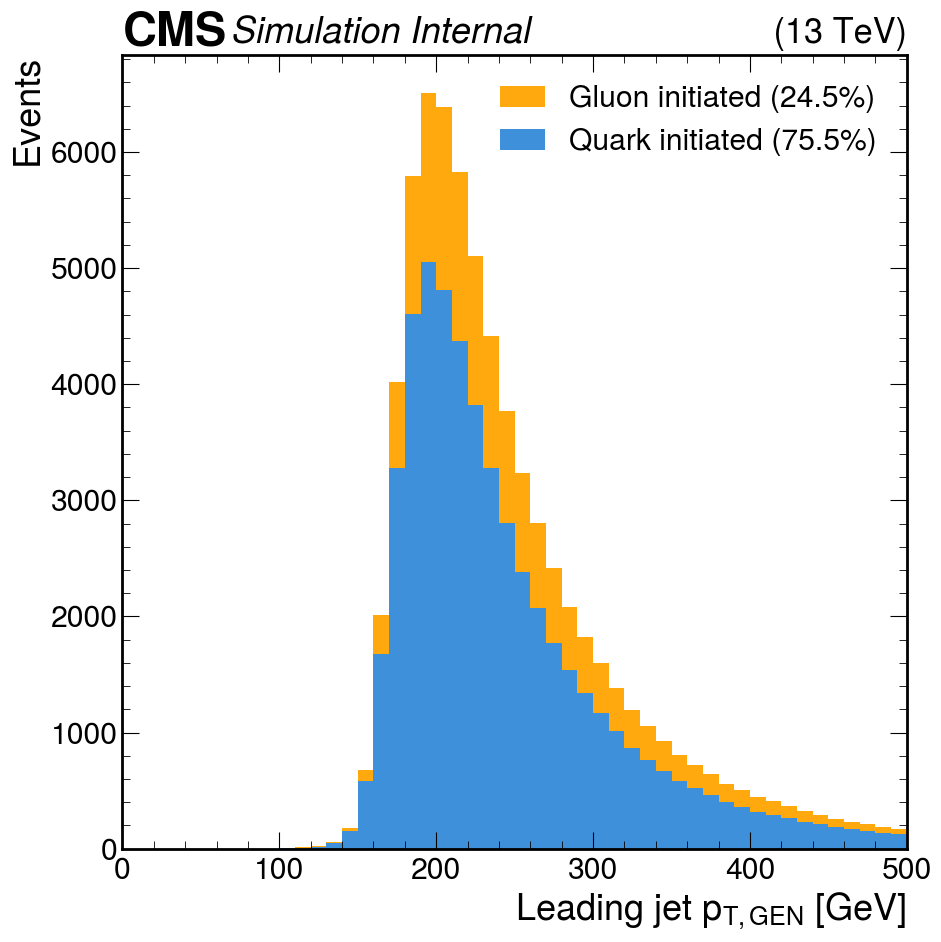

In [16]:
histunid = out['pt_flavor_jet0_gen'].project('pt', 'n')[:, 0]
histgluon = out['pt_flavor_jet0_gen'].project('pt', 'n')[:, 2]
histquark = out['pt_flavor_jet0_gen'].project('pt', 'n')[:, 1]

import mplhep as hep
import matplotlib.pyplot as plt

plt.style.use(hep.style.CMS)

# --- Fractions ---
total_quark = histquark.sum().value
total_gluon = histgluon.sum().value
total = total_quark + total_gluon

fq = total_quark / total
fg = total_gluon / total

# --- Labels with fractions ---
label_quark = f"Quark initiated ({fq*100:.1f}%)"
label_gluon = f"Gluon initiated ({fg*100:.1f}%)"

# --- Plot ---
hep.histplot(
    [histquark, histgluon],
    stack=True,
    histtype="fill",
    label=[label_quark, label_gluon],
    color=["#3f90da", "#ffa90e"],
    edgecolor="black"
)

plt.legend()

plt.xlim(0, 500)
plt.xlabel(r"Leading jet $p_{T, GEN}$ [GeV]")
plt.ylabel("Events")

hep.cms.label("Internal", data=False)

plt.tight_layout()
plt.show()

In [9]:
# for key in out.keys():
#     if key in ("sumw", "nev", "cutflow"):
#         continue
#     print(key, out[key].sum())